## 경사 하강법(Gradient Descent)
* 점진적인 하강. 점진적으로 반복적 계산을 통해 W 파라미터값을 업데이트하며 오류값이 최소가 되는 W 파라미터 구하는 방식
* 방법
  * 비용함수 RSS(w0, w1)를 편의상 R(w)라 하자. 
  * 변수가 w 파라미터로 이뤄진 함수임 -> w를 미분해서 미분함수의 최솟값을 구하고자 함 -> w가 2개이므로 편미분 적용해야
  * 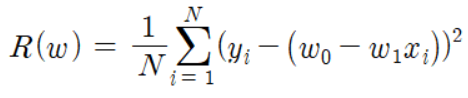
  * 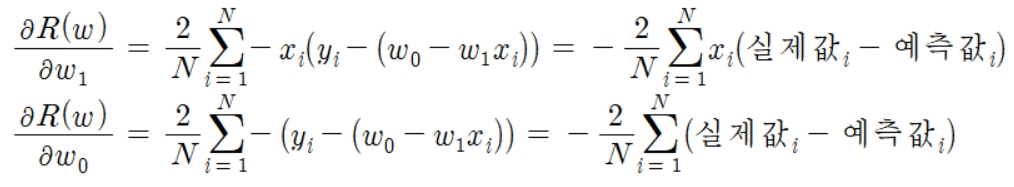
  * 각 변수의 편미분 결괏값을 반복적으로 보정하며 w1, w0 값을 업데이트하며, 비용함수 R(w)가 최소가 되는 두 w를 구하기
  * 업데이트는 w1를 이전 w1에서 편미분 결괏값을 마이너스하며 적용
    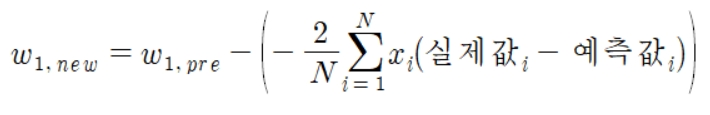
  * 위 편미분값이 매우 클 수 있어, 보정계수 eta, 즉 학습률을 곱함
* 프로세스 다시 정리
  1. w1, w0을 임의의 값으로 설정하고, 첫 비용함수의 값을 계산
  2. w1, w0을 각각 아래와 같이 업데이트하고, 다시 비용함수 값 계산
  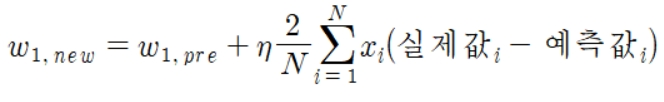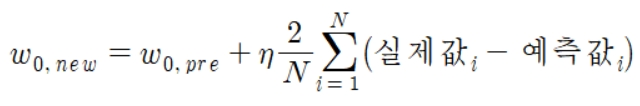

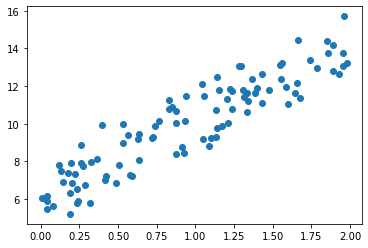

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
#y=4x+6을 근사(w1=4, w0=6). 임의의 값은 노이즈를 위해 만듦
x = 2*np.random.rand(100, 1)
y = 6 + 4*x + np.random.randn(100, 1)

plt.scatter(x, y)

In [5]:
# 비용함수
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost

# w1, w0을 업데이트할 값 반환 - 수식 설명은 책 298 참조
def get_weight_updates(w1, w0, x, y, learning_rate=0.01):
    N = len(y)
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    y_pred = np.dot(x, w1.T) + w0
    diff = y - y_pred
    
    w0_factors = np.ones((N, 1))
    w1_update = -(2/N) * learning_rate * (np.dot(x.T, diff))
    w0_update = -(2/N) * learning_rate * (np.dot(w0_factors.T, diff))
    
    return w1_update, w0_update

# w1, w0을 업데이트할 함수
def gradient_descent_steps(x, y, iters=10000):
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))
    
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, x, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
        
    return w1, w0

In [7]:
w1, w0 = gradient_descent_steps(x, y, iters=1000)
print('w1 = {0:.3f}\tw0= = {1:.3f}'.format(w1[0, 0], w0[0, 0]))
y_pred = w1[0, 0] * x + w0
print('Gradient Descent Total Cost : {0:.4f}'.format(get_cost(y, y_pred)))
  #실제 수식인 4x+6의 계수와 비슷하게 나옴. 예측 오류 비용이 0.9935

w1 = 4.022	w0= = 6.162
Gradient Descent Total Cost : 0.9935


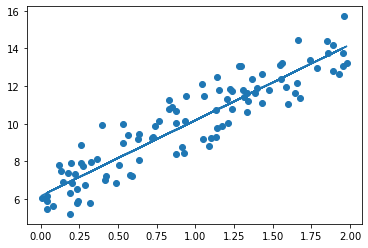

In [8]:
# 회귀선 그리기
plt.scatter(x, y)
plt.plot(x, y_pred)

# 확률적 경사 하강법(Stochastic Gradient Descent)
* 일반적 경사 하강법은 모든 학습 데이터에 대해 반복적으로 비용 함수 최소화할 업데이트 -> 수행시간 오래 걸림
* 실전에서는 확률적 경사 하강법을 이용. 또는 미니 배치 확률적 경사 하강법
* 일부 데이터만 이용해 w가 업데이트되는 값을 계산

In [9]:
# 미니 배치 확률적 경사 하강법 함수
def stochastic_gradient_descent_steps(x, y, batch_size=10, iters=1000):
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))
    prev_cost = 100000
    iter_index = 0
    
    for ind in range(iters):
        np.random.seed(ind)
        stochastic_random_index = np.random.permutation(x.shape[0])
        sample_x= x[stochastic_random_index[0:batch_size]]
        sample_y= y[stochastic_random_index[0:batch_size]]
        w1_update, w0_update = get_weight_updates(w1, w0, sample_x, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
        
    return w1, w0

In [10]:
w1, w0 = stochastic_gradient_descent_steps(x, y, iters=1000)
print('w1 = {0:.3f}\tw0= = {1:.3f}'.format(w1[0, 0], w0[0, 0]))
y_pred = w1[0, 0] * x + w0
print('Stochastic Gradient Descent Total Cost : {0:.4f}'.format(get_cost(y, y_pred)))
  #실제 수식인 4x+6의 계수와 비슷하게 나옴. 예측 오류 비용이 0.9937

w1 = 4.028	w0= = 6.156
Stochastic Gradient Descent Total Cost : 0.9937


# 복수 피처를 가졌을 때 경사 하강법
* 피처가 M개 있다면 그에 따른 회귀 계수도 M+1개 있음. 예측 회귀 식은 다음과 같을 것
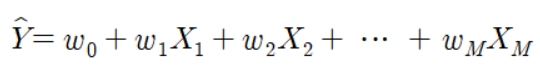
* 회귀 계수 많아지더라도 선형태수로 예측값 도출 가능 : 데이터 개수 N개이고 피처가 M개인 입력행렬 Xmat이라 할 때 예측 행렬은 다음과 같음
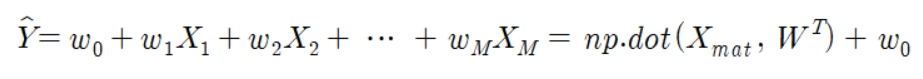
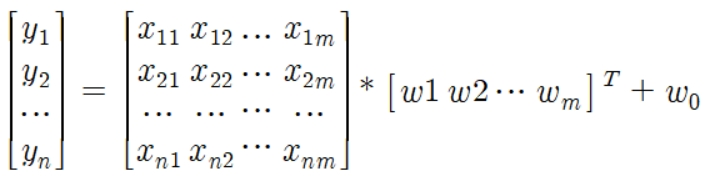
* w0을 weight의 배열인 W안에 포함시키려 Xmat의 맨 처음 열에 모든 데이터값이 1인 피처를 추가 -> y-hat = Xmat * W.T
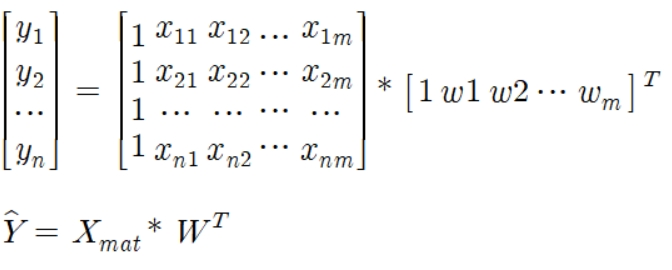